# Image Compression Using Principal Component Analysis.

<hr>
<h3>Anshu Chaudhary</h3> <hr><h4>3 Jan 2023

---
# Reducing the Dimension with PCA
<br>
Principal component analysis (PCA) is a common technique for image compression. PCA is a linear dimensionality reduction technique that is often used to reduce the number of dimensions in a dataset while retaining as much information as possible.

In the context of image compression, PCA can be used to identify the dominant patterns in the image, and represent the image using a smaller number of dimensions that capture these patterns. This can be useful for reducing the size of the image, which can be useful for storage and transmission.

### Necessary Imports

In [1]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt


### Import the image

Pixel type: uint8
Image size: (2039, 1492)


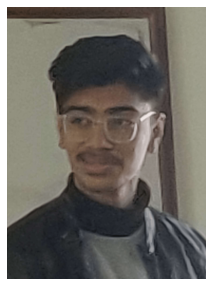

In [2]:
# Load the image and convert it to grayscale
image = Image.open('img2.png')

# stores the image in Numpy array.
pixels = np.array(image)

print('Pixel type:', pixels.dtype) 
print('Image size:', pixels.shape)

plt.figure(figsize=(5, 5))
plt.imshow(image,cmap = plt.cm.gray)
plt.axis('off')
plt.show()

---
## Convert Image to grayscale

Pixel type: uint8
Image size: (2039, 1492)


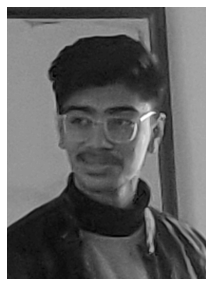

In [3]:
image = image.convert('L')
# stores the image in Numpy array.
pixels = np.array(image)

print('Pixel type:', pixels.dtype) 
print('Image size:', pixels.shape)

plt.figure(figsize=(5, 5))
plt.imshow(image,cmap = plt.cm.gray)
plt.axis('off')
plt.show()

___
### Prepare Standarize the Data.

To give all the features the same scale and makes the results more interpretable. Standardization of data is done, which satisfies the following expression:

\begin{align}
\mathbf{X_{std}}= \mathbf{X} - \mathbf{X_{mean}} / Standard Deviation(X)\
\end{align}
___

In [4]:
def standardize_pixels(pixels):
    ''' Standardize the pixel values by subtracting the mean and dividing by the standard deviation '''
    mean = np.mean(pixels)
    std = np.std(pixels)
    return (pixels - mean) / std

standardize_pixels(pixels).shape

(2039, 1492)

### Calculate the eigenvectors and eigenvalues of the covariance matrix: 
---
The eigenvectors and eigenvalues of the covariance matrix are used to determine the principal components of the data. 
##### To calculate covariance matrix:
As each element of the covarince matrix represents covariance between each $ij^{th} element. $ The covarince between two elements is calculated as follows:
\begin{align}
        \sum = 1/n-1 ((X - \bar x)^T (X - \bar x))
\end{align}

or in code:

\begin{align}
        cov = (X\_std - mean\_vec).T.dot((X\_std - mean\_vec)) / (X\_std.shape[0]-1)
\end{align}

Here we have simply used the .cov() function from numpy that computes the covariance of a matrix:

\begin{align}
        np.cov(X\_std)
\end{align}

##### To calculate the eigenvectors and eigenvalues, we have used the eig() function from NumPy on the covariance matrix.

In [5]:
def calculate_eigenpair(pixels):
    '''Returns a list if tuples (eigenvalue, eigenvector) of an array'''
    # Calculate the covariance matrix
    cov = np.cov(standardize_pixels(pixels))

    # Calculate the eigenvectors and eigenvalues of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Make a list of (eigenvalue, eigenvector) tuples
    eigen_pairs = [(np.abs(eigenvalues[i]), eigenvectors[:,i]) for i in range(len(eigenvalues))]
    
    # Sort the tuples from high to low based on eigenvalues
    eigen_pairs.sort(key=lambda x: x[0], reverse=True)

    return eigen_pairs

Sort the eigenvectors in decreasing order of the corresponding eigenvalues: The eigenvectors with the largest eigenvalues are the ones that contribute the most to the variance in the data, so it is generally a good idea to sort the eigenvectors in decreasing order of the corresponding eigenvalues.

In [6]:
eigen_pairs = calculate_eigenpair(pixels)
eigenvalues = [pair[0] for pair in eigen_pairs[:5]]
eigenvectors = [pair[1] for pair in eigen_pairs[:5]]

eigenvalues,eigenvectors

([800.2446834884656,
  168.91211137242138,
  123.31623555817178,
  83.84517686054497,
  65.21114482803486],
 [array([ 0.01371564,  0.01382385,  0.01387228, ..., -0.0032557 ,
         -0.00319755, -0.00314419]),
  array([0.03725899, 0.03716667, 0.03731108, ..., 0.02886854, 0.02897664,
         0.02918046]),
  array([-0.00381841, -0.00351587, -0.00342266, ...,  0.02744775,
          0.02722995,  0.02708048]),
  array([ 0.03009441,  0.02985872,  0.02984578, ..., -0.02138046,
         -0.02111181, -0.02129062]),
  array([-0.00898749, -0.00968209, -0.00930953, ..., -0.03094512,
         -0.03096745, -0.0310088 ])])

Identify the Principal Components.
---

After sorting the eigenpairs, to answer the next question of "how many principal components are we going to choose for our new feature subspace?" We'll look at the scree-plot to assess how many components we could retain and how much cumulative explained variance they capture.

The explained variance tells us how much information (variance) can be attributed to each of the principal components.

A scree plot is a graphical representation of the explained variance ratio of the principal components. It can be used to visualize the amount of variance explained by each principal component. The value of K can be chosen by selecting the number of components that explain a significant amount of variance in the data.

In [7]:
def plot_cum_var_exp(pixels,percentage):
    '''creates a graphical representation of the explained variance ratio of the principal components
        by taking arguments for array and % of variance to retain'''
    eigen_pairs = calculate_eigenpair(pixels)
    #selecting eigenvalues
    eigenvalues = [pair[0] for pair in eigen_pairs]
    tot = sum(eigenvalues)
    # Getting the explained variance
    var_exp = [(i / tot)*100 for i in sorted(eigenvalues, reverse=True)]
    # Getting the cumulative explained variance
    cum_var_exp = np.cumsum(var_exp)
    k = np.argmax(cum_var_exp>percentage)
    print("Number of components explaining",percentage,"% variance: "+ str(k))
    plt.style.use('seaborn-whitegrid')
    plt.figure(figsize=(15, 7))
    plt.title('Cumulative Explained Variance explained by the components')
    plt.ylabel('Cumulative Explained variance')
    plt.xlabel('Principal components')
    plt.axvline(x=k, color="b", linestyle="--")
    plt.axhline(y=percentage, color="r", linestyle="--")
    ax = plt.plot(cum_var_exp)

Number of components explaining 99.9 % variance: 216


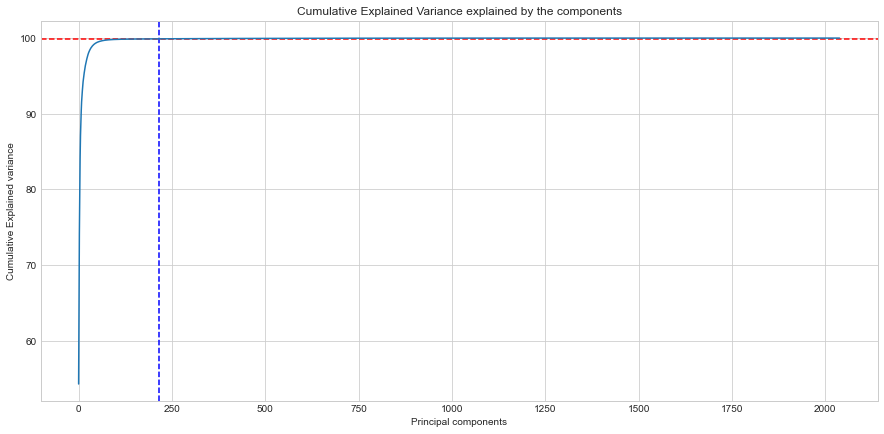

In [8]:
plot_cum_var_exp(pixels,99.9)

#### From the above plot we can see that 216 components, instead of 2039 pixels, can explain 99.9% of the variance in the image

---
# Selecting a smaller number of dimensions to represent the image
The top K eigenvectors are used to project the data onto the lower-dimensional space. You can choose the value of K based on the amount of variance you want to preserve in the data.

Then project the data onto the subspace spanned by the selected eigenvectors, to project the data onto the lower-dimensional space, the dot product of the data matrix with the transpose of the matrix formed by the top K eigenvectors is taken.

### The lower-dimensional representation of the image is then used to reconstruct the original image
___

In [9]:
def reconstruct_image(pixels,K):
    s_pixels = standardize_pixels(pixels)
    eigen_pairs = calculate_eigenpair(s_pixels)
    
    # Select the top K eigenvectors
    eigenvectors = np.column_stack([pair[1] for pair in eigen_pairs[:K]])

    # Project the image onto the subspace spanned by the selected eigenvectors
    projection = np.dot(eigenvectors.T, s_pixels)

    # Reconstruct the image from the lower-dimensional representation
    reconstruction = np.dot(eigenvectors, projection)

    # Rescale the reconstruction by multiplying by the standard deviation and adding the mean
    reconstruction = reconstruction * np.std(pixels) + np.mean(pixels)

    # Convert the reconstructed image to an 8-bit integer
    reconstruction = reconstruction.astype(np.uint8)
    
    # Save the reconstructed image
    im = Image.fromarray(reconstruction)
    return im

## Reconstruction of image with variance 99.9

(-0.5, 1491.5, 2038.5, -0.5)

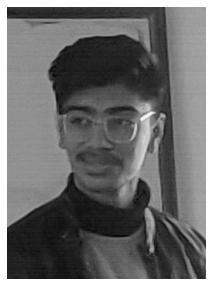

In [10]:
plt.figure(figsize=(5, 5))
im = reconstruct_image(pixels,216)
im.save('compressed_image.png')
plt.imshow(im,cmap = plt.cm.gray)
plt.axis('off')

We can see that the image is almost identical to the original

Lets try it with different number of components

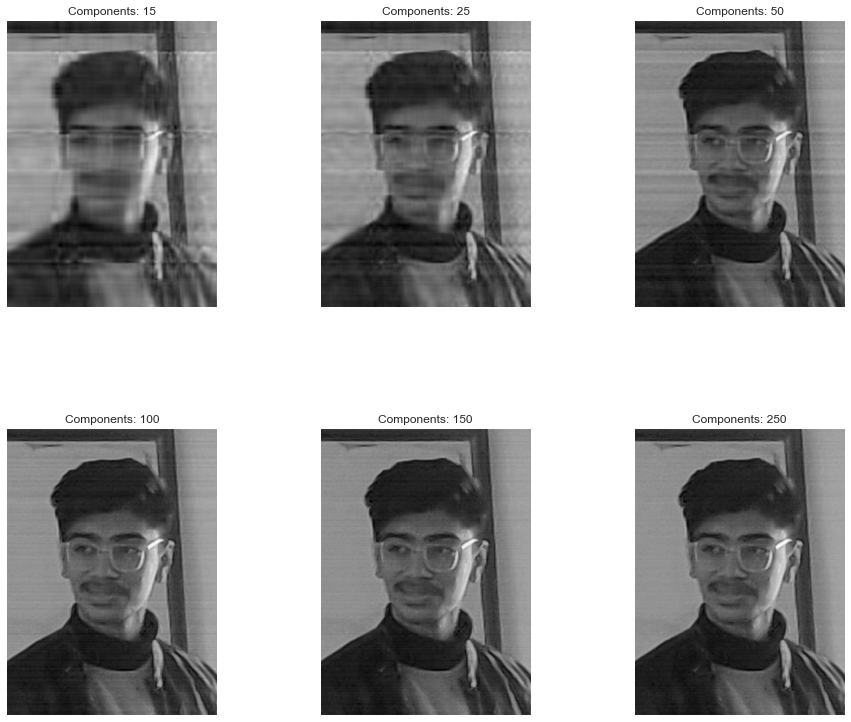

In [11]:
kv = [15, 25, 50, 100, 150, 250]

plt.figure(figsize=[15,15])

for i in range(6):
    plt.subplot(2,3,i+1)
    im = reconstruct_image(pixels,kv[i])
    plt.imshow(im,cmap = plt.cm.gray)
    plt.axis('off')
    plt.title("Components: "+str(kv[i]))

plt.subplots_adjust(wspace=0.5, hspace=0)

We can see that almost minimal change can be seen as the number of components pass 100

### Another example image

Number of components explaining 95 % variance: 28


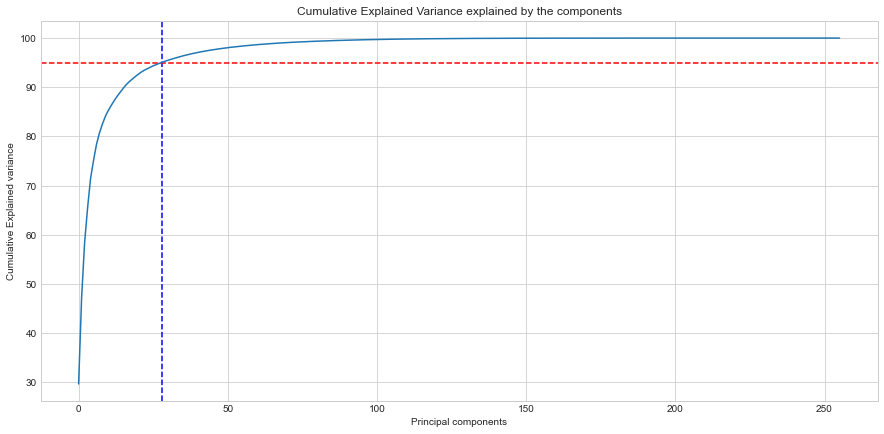

In [12]:
lena = np.array(Image.open('Lena.png').convert('L'))
plot_cum_var_exp(lena,95)

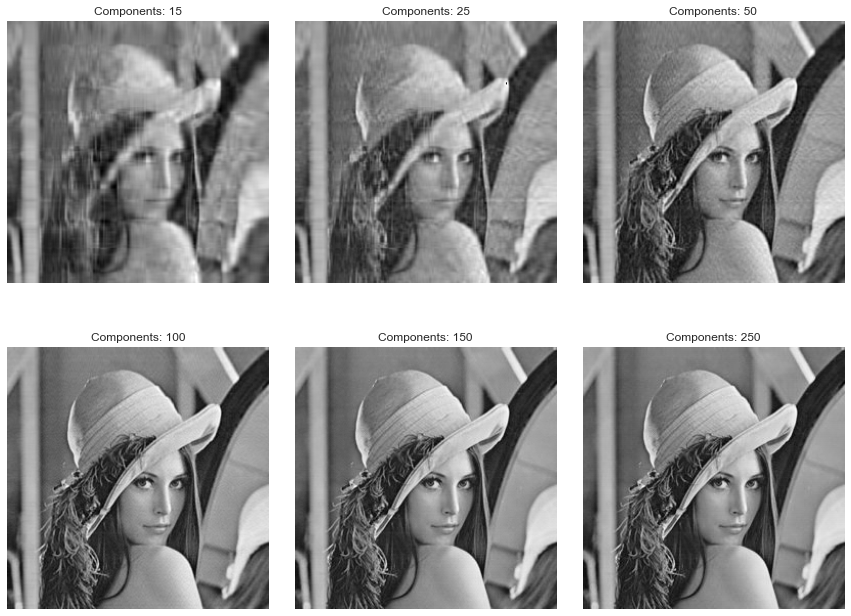

In [13]:
plt.figure(figsize=[15,12])

for i in range(6):
    plt.subplot(2,3,i+1)
    im = reconstruct_image(lena,kv[i])
    plt.imshow(im,cmap = plt.cm.gray)
    plt.axis('off')
    plt.title("Components: "+str(kv[i]))

plt.subplots_adjust(wspace=0.1, hspace=0.0)
plt.show()

Here we can see that almost no change occurs pass 100 components

### Image Format Comparison

(-0.5, 778.5, 856.5, -0.5)

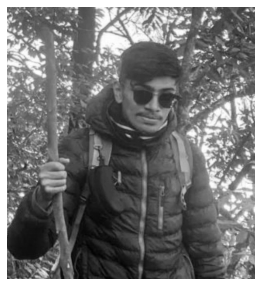

In [14]:
a = np.array(Image.open('image100.png').convert('L'))
plt.figure(figsize=(5, 5))
im = reconstruct_image(a,1000)
im.save('compressed_image.png')
plt.imshow(im,cmap = plt.cm.gray)
plt.axis('off')

(-0.5, 778.5, 856.5, -0.5)

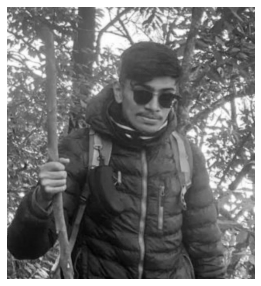

In [15]:
b = np.array(Image.open('image100.jpeg').convert('L'))
plt.figure(figsize=(5, 5))
im = reconstruct_image(b,1000)
im.save('compressed_image.jpeg')
plt.imshow(im,cmap = plt.cm.gray)
plt.axis('off')

In [16]:
def compression_ratio(a,b):
    '''Calculates compression ratio'''
    # Open the original image
    original_image = Image.open(a)

    # Get the file size of the original image
    original_image_size = os.path.getsize(a)

    # Save the compressed image
    compressed_image = Image.open(b)
    compressed_image.save(b)

    # Get the file size of the compressed image
    compressed_image_size = os.path.getsize(b)

    # Calculate the compression ratio
    compression_ratio = original_image_size / compressed_image_size

    print("Compression ratio: {:.2f}".format(compression_ratio))


In [17]:
def psnr(a,b):
    '''Calculates Peak signal-to-noise ratio'''
    # Open original and compressed images
    original_image = Image.open(a)
    compressed_image = Image.open(b)

    # Convert the images to numpy arrays
    original_image = np.array(original_image)
    compressed_image = np.array(compressed_image)

    # Calculate the MSE
    mse = np.mean((original_image - compressed_image) ** 2)

    # Calculate the PSNR
    psnr = 10 * np.log10(255 ** 2 / mse)

    print("PSNR: {:.2f} dB".format(psnr))

In [18]:
print("png :")
compression_ratio('image100.png','compressed_image.png')
print("jpeg :")
compression_ratio('image100.jpeg','compressed_image.jpeg')

png :
Compression ratio: 1.12
jpeg :
Compression ratio: 1.00


In [19]:
print("png :")
psnr('image100.png','compressed_image.png')
print("jpeg :")
psnr('image100.jpeg','compressed_image.jpeg')

png :
PSNR: 51.75 dB
jpeg :
PSNR: 52.11 dB


With the same number of principal components, PCA reduces the size of png images more at the cost of quality in comparision to jpeg.

---

### Comparing PCA with DCT(Discrete cosine transform)

In [20]:
from scipy.fftpack import dct, idct

def DCT(image,x):
    # Convert the image to a numpy array
    image_array = np.array(image)

    # Perform 2D DCT
    image_dct = dct(dct(image_array, axis=0, norm='ortho'), axis=1, norm='ortho')

    # Set a threshold for the DCT coefficients to retain
    threshold = x

    # Zero out the DCT coefficients below the threshold
    image_dct[np.abs(image_dct) < threshold] = 0

    # Perform 2D IDCT
    compressed_image = idct(idct(image_dct, axis=0, norm='ortho'), axis=1, norm='ortho')

    # Convert the compressed image to an Image object
    compressed_image = Image.fromarray(np.uint8(compressed_image))
    return compressed_image

(-0.5, 1491.5, 2038.5, -0.5)

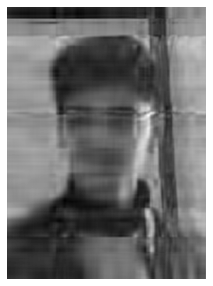

In [21]:
plt.figure(figsize=(5, 5))
a = Image.open('img2.jpeg').convert('L')
a.save('a_gray.jpeg')
im = reconstruct_image(a,10)
im.save('compressed_image.jpeg')
plt.imshow(im,cmap = plt.cm.gray)
plt.axis('off')

(-0.5, 1491.5, 2038.5, -0.5)

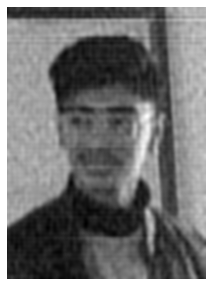

In [22]:
plt.figure(figsize=(5, 5))
im = DCT(a,440)
im.save('compressed_image2.jpeg')
plt.imshow(im,cmap = plt.cm.gray)
plt.axis('off')

In [23]:
print("PCA :")
compression_ratio('a_gray.jpeg','compressed_image.jpeg')
print("DCT :")
compression_ratio('a_gray.jpeg','compressed_image2.jpeg')

PCA :
Compression ratio: 1.09
DCT :
Compression ratio: 1.09


Same size files

In [24]:
print("PCA :")
psnr('a_gray.jpeg','compressed_image.jpeg')
print("DCT :")
psnr('a_gray.jpeg','compressed_image2.jpeg')

PCA :
PSNR: 29.88 dB
DCT :
PSNR: 31.96 dB


Image compressed with DCT is of higher quality

### Here we see that DCT is alot better than PCA when comparing quality 

---
## Summary
<p>Principal Component Analysis (PCA) is a useful technique for image compression because it allows for the reduction of the dimensionality of an image while preserving the most important information. By selecting the most significant eigenvalues and eigenvectors, PCA can represent an image using a smaller number of components, resulting in a compressed image with minimal loss of quality. Additionally, PCA is fast and easy to implement, making it a practical choice for image compression.</p> <br>
<p>However, it is important to note that PCA may not always be the best method for image compression, as it may not always provide the optimal trade-off between size and quality. In these cases, other techniques such as Discrete Cosine Transform (DCT) or Fractal Compression may be more suitable. Overall, PCA is a useful tool for image compression and can be applied in a variety of image processing tasks.</p>

---